![RMIT logo](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTlAppozhCGl50pjgEZu_tTmalWJi3TjpNwCg&s)
|Course|Foundations of Artificial Intelligence for STEM|
|-----|-------|
|Course Code|COSC2968/COSC3053|
|Lecturer(s)|Mr.Nhat-Quang Tran and Mrs.Anh Le Van|
|Full name - Student ID| Le Kim Quyen - s3983370<br>Ton Dat Toan - s4070286<br>Nguyen Hong Ha - s3979100<br>Huynh Bao Khoa Dang - s4045607<br>Nguyen Viet Ngan Anh - s4103086|

# Predicting the age of abalone

## Table of Contents
[1. Introduction](#intro) \
&emsp;[1.1. Overview](#intro_1) \
[2. Exploration Data Analysis (EDA)](#eda) \
&emsp;[2.1. Import Libraries and Modules](#eda_1) \
&emsp;[2.2. Load the dataset](#eda_2) \
&emsp;[2.3. Descriptive statistics, visualizations and correlation analysis](#eda_3) \
[3. Data Preprocessing](#data_preprocessing) \
&emsp;[3.1. Remove unused features](#data_preprocessing_1) \
&emsp;[3.2. Identify and handle outliers](#data_preprocessing_2) \
&emsp;[3.3. Split the data](#data_preprocessing_3) \
&emsp;[3.4. Separate labels from data](#data_preprocessing_4) \
&emsp;[3.5. Handle missing values](#data_preprocessing_5) \
&emsp;[3.6. Encode categorical features](#data_preprocessing_6) \
&emsp;[3.7. Scale numerical features](#data_preprocessing_7) \
[4. Model Training and Evaluation](#train_evaluate) \
&emsp;[4.1. Define support Functions](#train_evaluate_1) \
&emsp;&emsp;[4.1.1. R-squared (R2) and root mean squared error (RMSE) Function](#train_evaluate_1_1) \
&emsp;&emsp;[4.1.2. Function to store models](#train_evaluate_1_2) \
&emsp;[4.2. Training Models](#train_evaluate_2) \
&emsp;&emsp;[4.2.1. LinearRegression model](#train_evaluate_2_1) \
&emsp;&emsp;[4.2.2. DecisionTreeRegressor model](#train_evaluate_2_2) \
&emsp;&emsp;[4.2.3. RandomForestRegressor model](#train_evaluate_2_3) \
&emsp;&emsp;[4.2.4. ElasticNet model](#train_evaluate_2_4) \
&emsp;&emsp;[4.2.5. Gradient Boosting Regressor model](#train_evaluate_2_5) \
&emsp;&emsp;[4.2.6. Lasso model](#train_evaluate_2_6) \
&emsp;[4.3. Evaluate with K-fold cross validation](#train_evaluate_3) \
[5. Hyperparameter Fine-tuning](#hyperparameter) \
[6. Model Testing and Analysis](#test_anal) \
[7. References](#ref) \
[8. Contribution](#contribution)

## 1. Introduction <a class="anchor" id="intro"></a>

### 1.1. Overview <a id="intro_1"></a>
&emsp;Abalones are not only a rich source of nutrition but also provide therapeutic benefits to various diseases such as asthma, atherosclerosis, and heart disease (Suleria et al., 2017). Therefore, it has become one of the most sought-after luxury dishes in some global markets, such as Chile, France, China, Japan, Korea and Vietnam. The high demand for this item has led to an upsurge in the number of abalone farms and fisheries over the past few decades. Because of a potentially abundant supply, reducing costs is essential to keep the products competitive in the market (Cook, 2023). Although the value of abalone and its age have a positive correlation, the old method to determine its age is still slow, expensive and inefficient. Traditionally, an abalone shell must be sliced through the cone, stained, and examined under a microscope to count the rings, each of which represents one year of the abalone. Some rings can be difficult to distinguish, so the estimated age is often multiplied by 1.5 (Akanda et al., 2023). With the proposed AI integration, people can work on computer-based techniques instead of manual methods, making the age-determination process faster and more accurate. There might be an innovative method to estimate the age of abalone just from its physical characteristics, such as weight, height, diameter, sex, etc, without causing damage. This report will propose and analyse various machine learning models to find a new way to determine the age of abalone based on its physical features, which might reduce production costs.

*Write something here*

## 2. Exploration Data Analysis (EDA) <a class="anchor" id="eda"></a>

### 2.1. Import Libraries and Modules <a id="eda_1"></a>
Installing and getting started with Terminal (if necessary):
+ pip install matplotlib
+ pip install seaborn
+ pip install ydata-profiling
+ pip install ipywidgets
+ pip install scikit-learn

To install the necessary libraries / modules such as `pandas` [ref] for read dataset; `matplotlib` [ref], `seaborn` [ref] and `ydata` [ref] for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from statistics import mean

# run plots inline
%matplotlib inline

### 2.2. Load the dataset <a id="eda_2"></a>

In [2]:
abalone_df = pd.read_csv('Documents/Datasets/abalone.csv')
abalone_df.head() # Shows the first five samples

,Type,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


*Write something based on this format:*

**Catagorical Feature:**
+ `Type`: Type of abalones (M = male, F = female and I = infant)

**Numerical Features:**
+ `Length`: Longest shell measurement in mm (continuous)
+ `Diameter`: Perpendicular to length in mm (continuous)
+ `Height`: with meat in shell in mm (continuous)
+ `Whole weight`: whole abalone in g (continuous)
+ `Shucked weight`: weight of meat in g (continuous)
+ `Viscera weight`: gut weight (after bleeding) in g (continuous)
+ `Shell weight`: after being dried in g (continuous)
+ `Rings`: +1.5 gives the age in years (discrete)

In [3]:
abalone_df.info() # Shows overview of each feature

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           4177 non-null   object 
 1   LongestShell   4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


*Write something? Q - idk*

### 2.3. Descriptive statistics, visualizations and correlation analysis <a id="eda_3"></a>

**An overview using ydata** [ref]**:**

In [4]:
# An overview using ydata
ydata = ProfileReport(abalone_df, title = 'Abalone overview')
ydata.to_notebook_iframe()
ydata.to_file('Documents/Figures/abalone.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

*Write something? Q - idk*

**Scatter plot between every pair of feature using seaborn** [ref]**:**

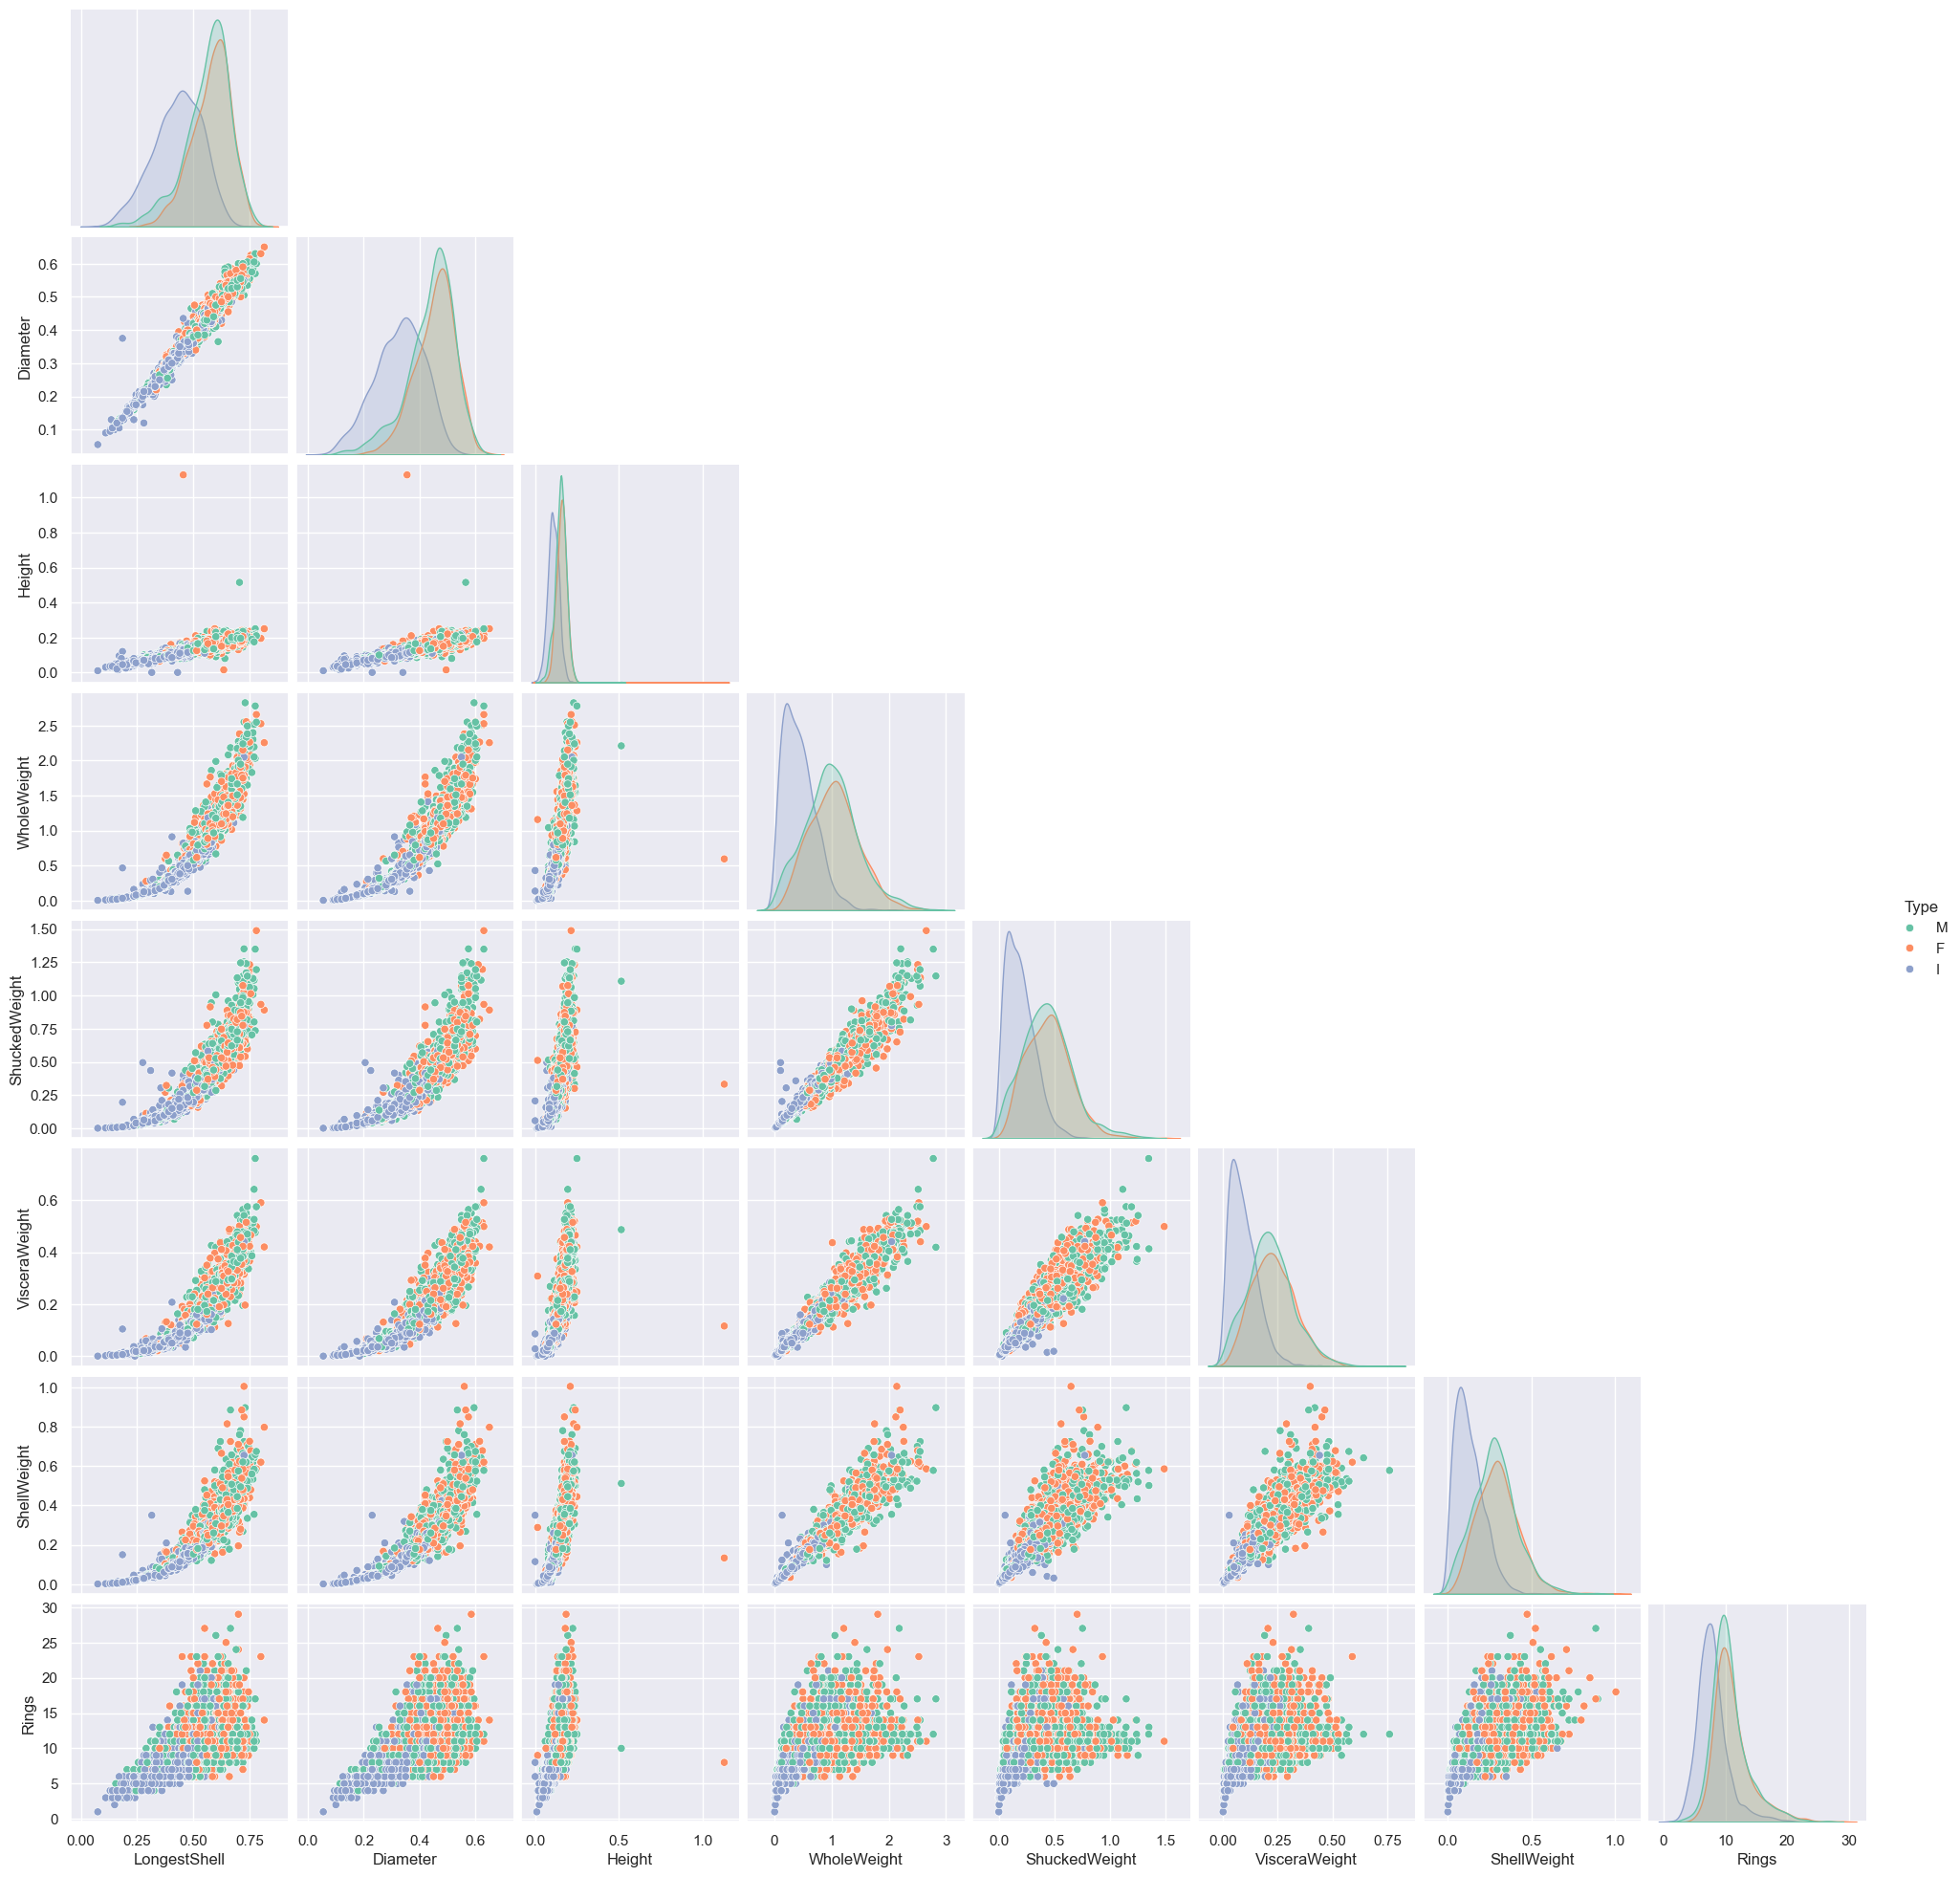

In [5]:
# An overview of the relationship between each pair feature
sns.set_theme() # set default theme for plot

# Plot features with each color for each type of abalone, including male (M), female (F) and infant (I)
sns.pairplot(data = abalone_df, hue = 'Type', corner = True, palette = 'Set2');

plt.savefig('Documents/Figures/pairplot.png') # save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**Compute correlations between features**

In [6]:
# The variable contains correlations between features
abalone_corr = abalone_df.corr(numeric_only = True)

# uncomment to see data as table
# abalone_corr

**Visualize using headmap from seaborn** [ref]**:**

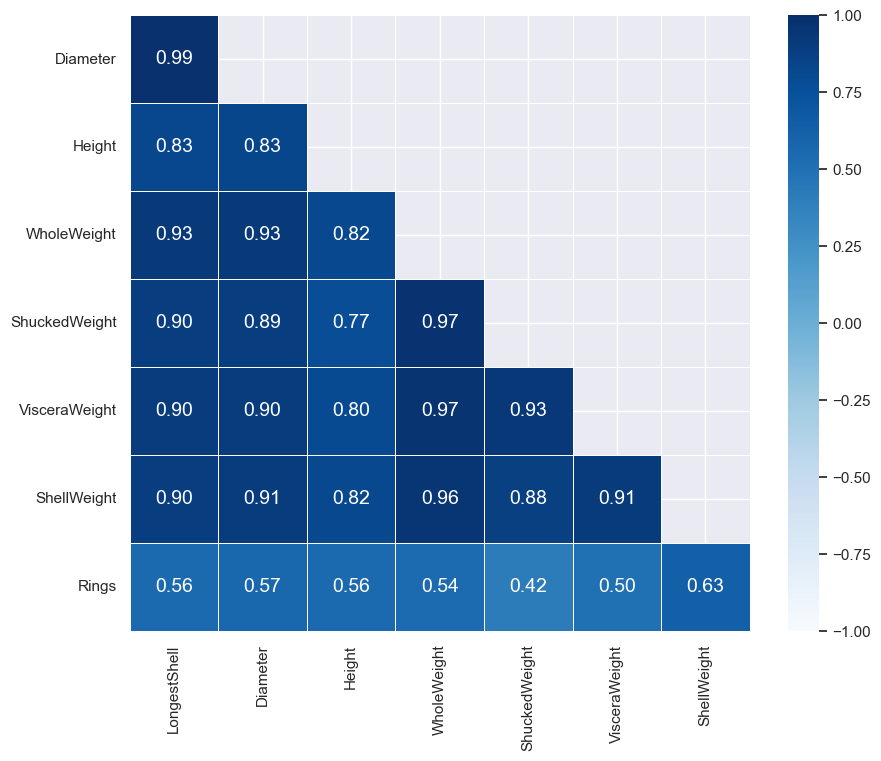

In [7]:
ones_corr = np.ones_like(abalone_corr, dtype = bool) # create a matrix contains boolean values with the same shape as abalone_corr
mask = np.triu(ones_corr) # a mask contains half triangle matrix of True and False

# Remove redundant the first row and the last column
adjusted_abalone_corr = abalone_corr.iloc[1:, :-1]
adjusted_mask_corr = mask[1:, :-1]

# Create plot
fig, ax = plt.subplots(figsize = (10, 8))

# Show heatmap
sns.heatmap(data = adjusted_abalone_corr, mask = adjusted_mask_corr, cmap = 'Blues',
            annot = True, fmt = '.2f', vmin = -1, vmax = 1,
            linecolor = 'white', linewidths = .5, annot_kws = {'fontsize': 14});

plt.savefig('Documents/Figures/heatmap.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**Distribution of Numerical feature values**

In [8]:
abalone_df.describe()

,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


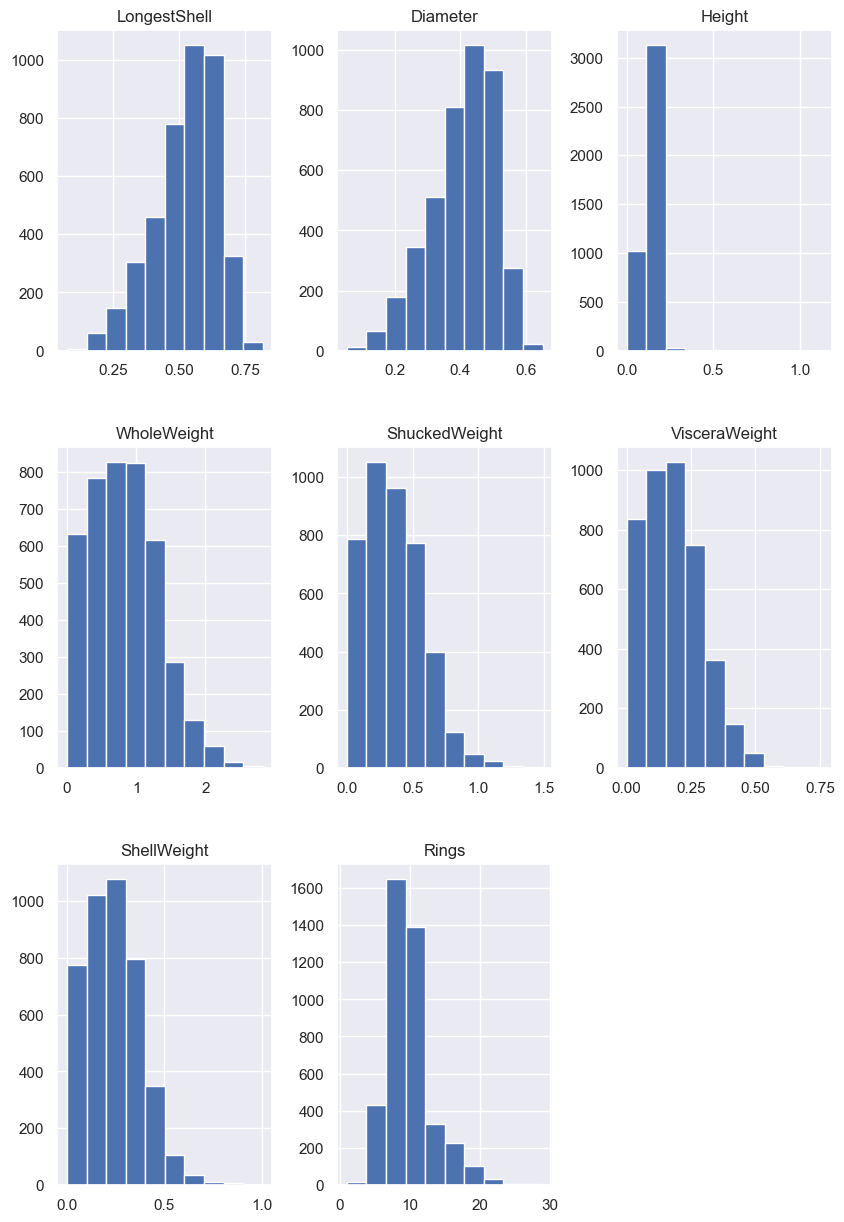

In [9]:
abalone_df.hist(figsize=(10,15))
plt.savefig('Documents/Figures/histmap.png')
plt.show()

*Write something? Q - idk*

**Distribution of Categorical feature values**

In [10]:
abalone_df.describe(include = 'object')

,Type
count,4177
unique,3
top,M
freq,1528


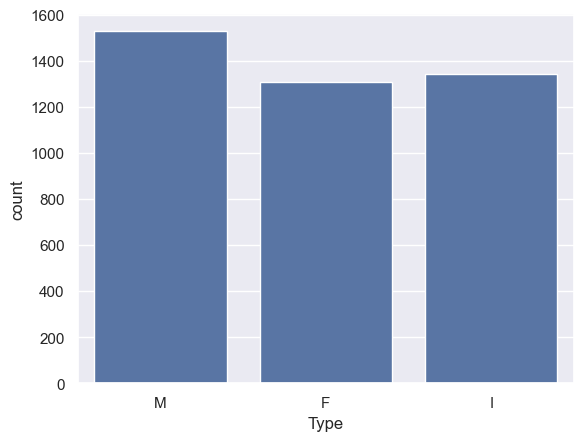

In [11]:
sns.countplot(data = abalone_df, x = 'Type');

*Write something? Q - idk*

**The relationship between LongestShell and Rings using jointplot from seaborn** [ref]**:**

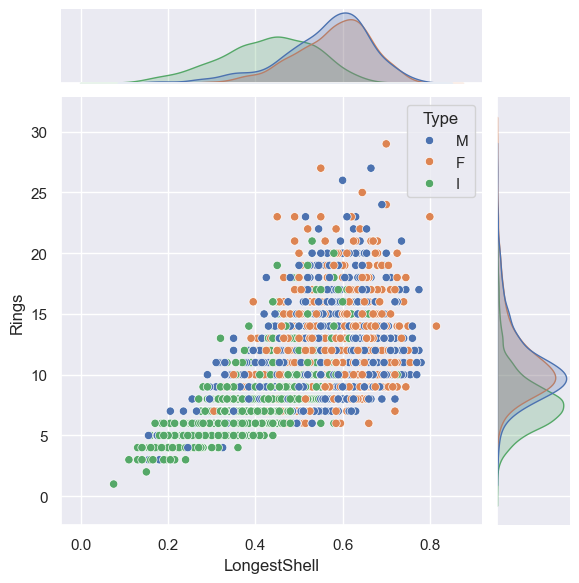

In [12]:
sns.jointplot(data = abalone_df, x = 'LongestShell', y = 'Rings', hue = 'Type');

plt.savefig('Documents/Figures/longestshell_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between Diameter and Rings using FacetGrid from seaborn** [ref]**:**

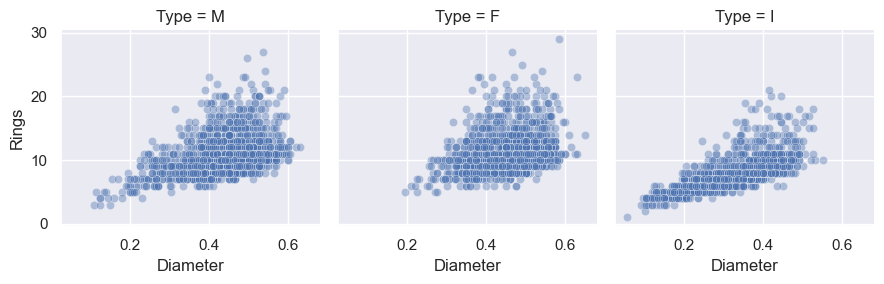

In [13]:
abalone_fg = sns.FacetGrid(data = abalone_df, col = 'Type')
abalone_fg.map(sns.scatterplot, 'Diameter', 'Rings', alpha = .4);

plt.savefig('Documents/Figures/diameter_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between Height and Rings using FaceGrid from seaborn** [ref]**:**

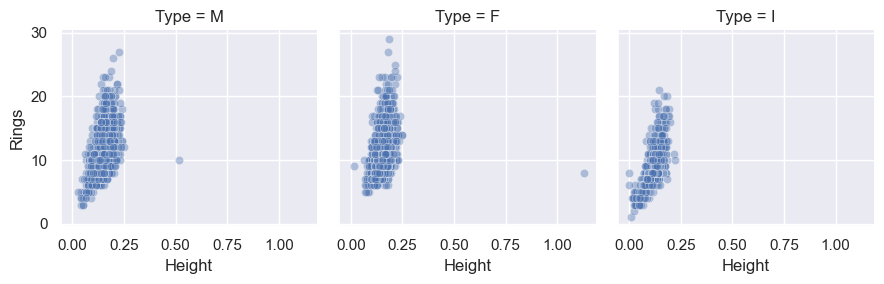

In [14]:
abalone_fg = sns.FacetGrid(data = abalone_df, col = 'Type')
abalone_fg.map(sns.scatterplot, 'Height', 'Rings', alpha = .4);

plt.savefig('Documents/Figures/height_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between WholeWeight and Rings using jointplot from seaborn** [ref]**:**

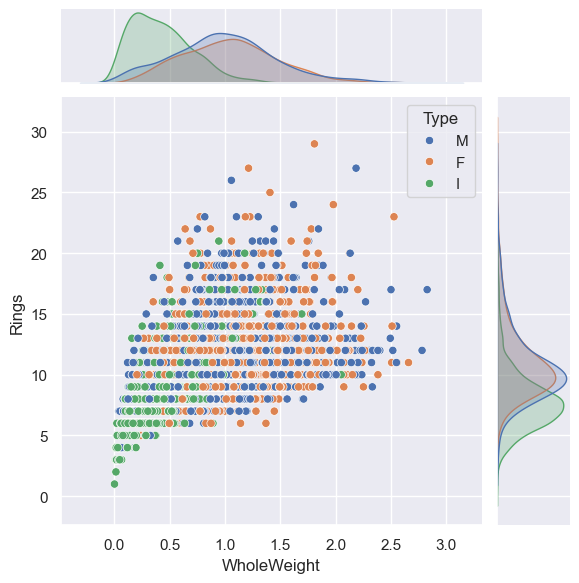

In [15]:
sns.jointplot(data = abalone_df, x = 'WholeWeight', y = 'Rings', hue = 'Type');

plt.savefig('Documents/Figures/wholeweight_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

## 3. Data Preprocessing <a id="data_preprocessing"></a>

### 3.1. Remove unused features <a id="data_preprocessing_1"></a>

In [16]:
abalone_df.drop(columns = ['ShuckedWeight', 'VisceraWeight', 'ShellWeight'], inplace = True)

# Uncomment to see the outcome
abalone_df

,Type,LongestShell,Diameter,Height,WholeWeight,Rings
0,M,0.455,0.365,0.095,0.5140,15
1,M,0.350,0.265,0.090,0.2255,7
2,F,0.530,0.420,0.135,0.6770,9
3,M,0.440,0.365,0.125,0.5160,10
4,I,0.330,0.255,0.080,0.2050,7
...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,11
4173,M,0.590,0.440,0.135,0.9660,10
4174,M,0.600,0.475,0.205,1.1760,9
4175,F,0.625,0.485,0.150,1.0945,10


*Write something? Q - idk*

### 3.2. Identify and handle outliers <a id="data_preprocessing_2"></a>
*Work here*

### 3.3. Split the data <a id="data_preprocessing_3"></a>

In [17]:
from sklearn.model_selection import train_test_split

# Split the raw data: abalone_train (80%) for training and abalone_test (20%) for testing with the percentage
abalone_train, abalone_test = train_test_split(abalone_df, test_size = 0.2, random_state = 25)

# Uncomment to se the outcome
abalone_train.shape, abalone_test.shape

((3341, 6), (836, 6))

### 3.4. Separate labels from data <a id="data_preprocessing_4"></a>
Choosing "Rings" column as the label.

In [18]:
# Split train set
train_set_labels = abalone_train['Rings'].copy()
train_set = abalone_train.drop(columns = 'Rings').copy()

# Split test set
test_set_labels = abalone_test['Rings'].copy()
test_set = abalone_test.drop(columns = 'Rings').copy()

*Write something? Q - idk*

### 3.5. Handle missing values <a id="data_preprocessing_5"></a>
There is no missing values to handle?? 😢

*Write something? Q - idk*

### 3.6. Encode categorical features <a id="data_preprocessing_6"></a>
There is one categorical feature in the dataset need to be encoded: `Type`

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create a class for encode columns
colTrans = ColumnTransformer(transformers = [('encode', OneHotEncoder(), [0])], remainder = 'passthrough')

# Encode
train_set = colTrans.fit_transform(train_set)
# train_set[0]
test_set = colTrans.transform(test_set)
# test_set[0]

In [20]:
# Transform label column sets into the same format (array) with the above sets
train_set_labels = train_set_labels.values
test_set_labels = test_set_labels.values

### 3.7. Scale numerical features <a id="data_preprocessing_7"></a>
Scale features to zero mean and unit variance.

In [21]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# Just only scale numerical features in training and testing set, not category feature
train_set[:, 3:] = std_scaler.fit_transform(train_set[:, 3:])
test_set[:, 3:] = std_scaler.transform(test_set[:, 3:])

## 4. Model Training and Evaluation <a id="train_evaluate"></a>

**Note:**
+ `train_set` contains set data for training
+ `train_set_labels` contains labels for training
+ `test_set` contains set data for testing
+ `test_set_labels` contains labels for testing

**Modules in lec:**
+ LinearRegression
+ DecisionTreeRegressor
+ RandomForestRegressor
+ PolynomialFeatures

### 4.1. Define support Functions <a id="train_evaluate_1"></a>

#### 4.1.1. R-squared (R2) and root mean squared error (RMSE) Function <a id="train_evaluate_1_1"></a>

In [22]:
from sklearn.metrics import mean_squared_error

def r2score_and_rmse(model, train_data, labels): 
    r2score = model.score(train_data, labels)
    prediction = model.predict(train_data)
    mse = mean_squared_error(labels, prediction)
    rmse = np.sqrt(mse)
    return r2score, rmse

#### 4.1.2. Functions to store and load models <a id="train_evaluate_1_2"></a>
Parameters:
+ `action`: to distinguish between models training and models evaluation
+ `model`: model
+ `model_name`: name of model

In [23]:
import joblib # new lib

def store_model(action, model, model_name = ''):
    # NOTE: sklearn.joblib faster than pickle of Python
    # INFO: can store only ONE object in a file
    if model_name == '': 
        model_name = type(model).__name__
    joblib.dump(model,f'Documents/Models/{model_name}_model_{action}.pkl')

def load_model(action, model_name):
    # Load objects into memory
    #del model
    model = joblib.load(f'Documents/Models/{model_name}_model_{action}.pkl')
    #print(model)
    return model

### 4.2. Training Models <a id="train_evaluate_2"></a>

#### 4.2.1. LinearRegression model <a id="train_evaluate_2_1"></a>

In [24]:
from sklearn.linear_model import LinearRegression

# Create an empty model
model = LinearRegression()

# Call function to training model
model.fit(train_set, train_set_labels)
print('\n____________ LinearRegression ____________')

# Compute R2 score and root mean squared error
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')
        
# Predict labels for some training instances (9 first samples)
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


____________ LinearRegression ____________

R2 score (on training data, best = 1): 0.40023473443280655
Root Mean Square Error: 2.5

Predictions:  [ 6.9 10.5  9.2 11.7 10.7 14.1 11.1 10.4  9.9]
Labels:       [6, 9, 9, 9, 10, 15, 9, 10, 11]


*Write something? Q - idk*

#### 4.2.2. DecisionTreeRegressor model <a id="train_evaluate_2_2"></a>

In [25]:
from sklearn.tree import DecisionTreeRegressor

# Create an empty model
model = DecisionTreeRegressor()

# Training model
model.fit(train_set, train_set_labels)

# Compute R2 score and root mean squared error
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ DecisionTreeRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict labels for some training instances (the first 9 samples)
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


____________ DecisionTreeRegressor ____________

R2 score (on training data, best = 1): 1.0
Root Mean Square Error: 0.0

Predictions:  [ 6.  9.  9.  9. 10. 15.  9. 10. 11.]
Labels:       [6, 9, 9, 9, 10, 15, 9, 10, 11]


*Write something? Q - idk*

#### 4.2.3. RandomForestRegressor model <a id="train_evaluate_2_3"></a>

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Create an empty model
model = RandomForestRegressor()

# Training model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ RandomForestRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


____________ RandomForestRegressor ____________

R2 score (on training data, best = 1): 0.9072502974819996
Root Mean Square Error: 1.0

Predictions:  [ 6.3  8.9  8.9 10.  10.4 14.4  9.4 10.4 11. ]
Labels:       [6, 9, 9, 9, 10, 15, 9, 10, 11]


*Write something? Q - idk*

#### 4.2.4. ElasticNet model <a id="train_evaluate_2_4"></a>

In [27]:
from sklearn.linear_model import ElasticNet

# Create Elastic net model
model = ElasticNet()

# Train the model 
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ ElasticNet ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)



____________ ElasticNet ____________

R2 score (on training data, best = 1): 0.315457095601711
Root Mean Square Error: 2.7

Predictions:  [ 8.  10.1  9.7 10.6 10.7 11.6 11.  10.8  9.2]
Labels:       [6, 9, 9, 9, 10, 15, 9, 10, 11]


*Write something? Q - idk*

#### 4.2.5. Gradient Boosting Regressor <a id="train_evaluate_2_5"></a>
`n_estimators` : the number of boosting stages that will be performed. Later, we will plot deviance against boosting iterations.

`max_depth` : limits the number of nodes in the tree. The best value depends on the interaction of the input variables.

`min_samples_split` : the minimum number of samples required to split an internal node.

`learning_rate` : how much the contribution of each tree will shrink.

`loss` : loss function to optimize. The least squares function is used in this case however, there are many other options

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
model = GradientBoostingRegressor(**params)

# Train the model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ GradientBoostingRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)



____________ GradientBoostingRegressor ____________

R2 score (on training data, best = 1): 0.5106338523321703
Root Mean Square Error: 2.3

Predictions:  [ 6.6 10.3  8.7 11.9 10.6 14.8 10.8 10.5  9.6]
Labels:       [6, 9, 9, 9, 10, 15, 9, 10, 11]


*Write something? Q - idk*

#### 4.2.6. Lasso model <a id="train_evaluate_2_6"></a>

In [29]:
from sklearn.linear_model import Lasso

# Create the model
model = Lasso(alpha=0.1)

# Train the model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ Lasso ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


____________ Lasso ____________

R2 score (on training data, best = 1): 0.3871289010600648
Root Mean Square Error: 2.6

Predictions:  [ 7.1 10.2  9.3 11.1 10.9 13.8 11.2 10.7  9.4]
Labels:       [6, 9, 9, 9, 10, 15, 9, 10, 11]


*Write something? Q - idk*

### 4.3. Evaluate with K-fold cross validation <a id="train_evaluate_3"></a>
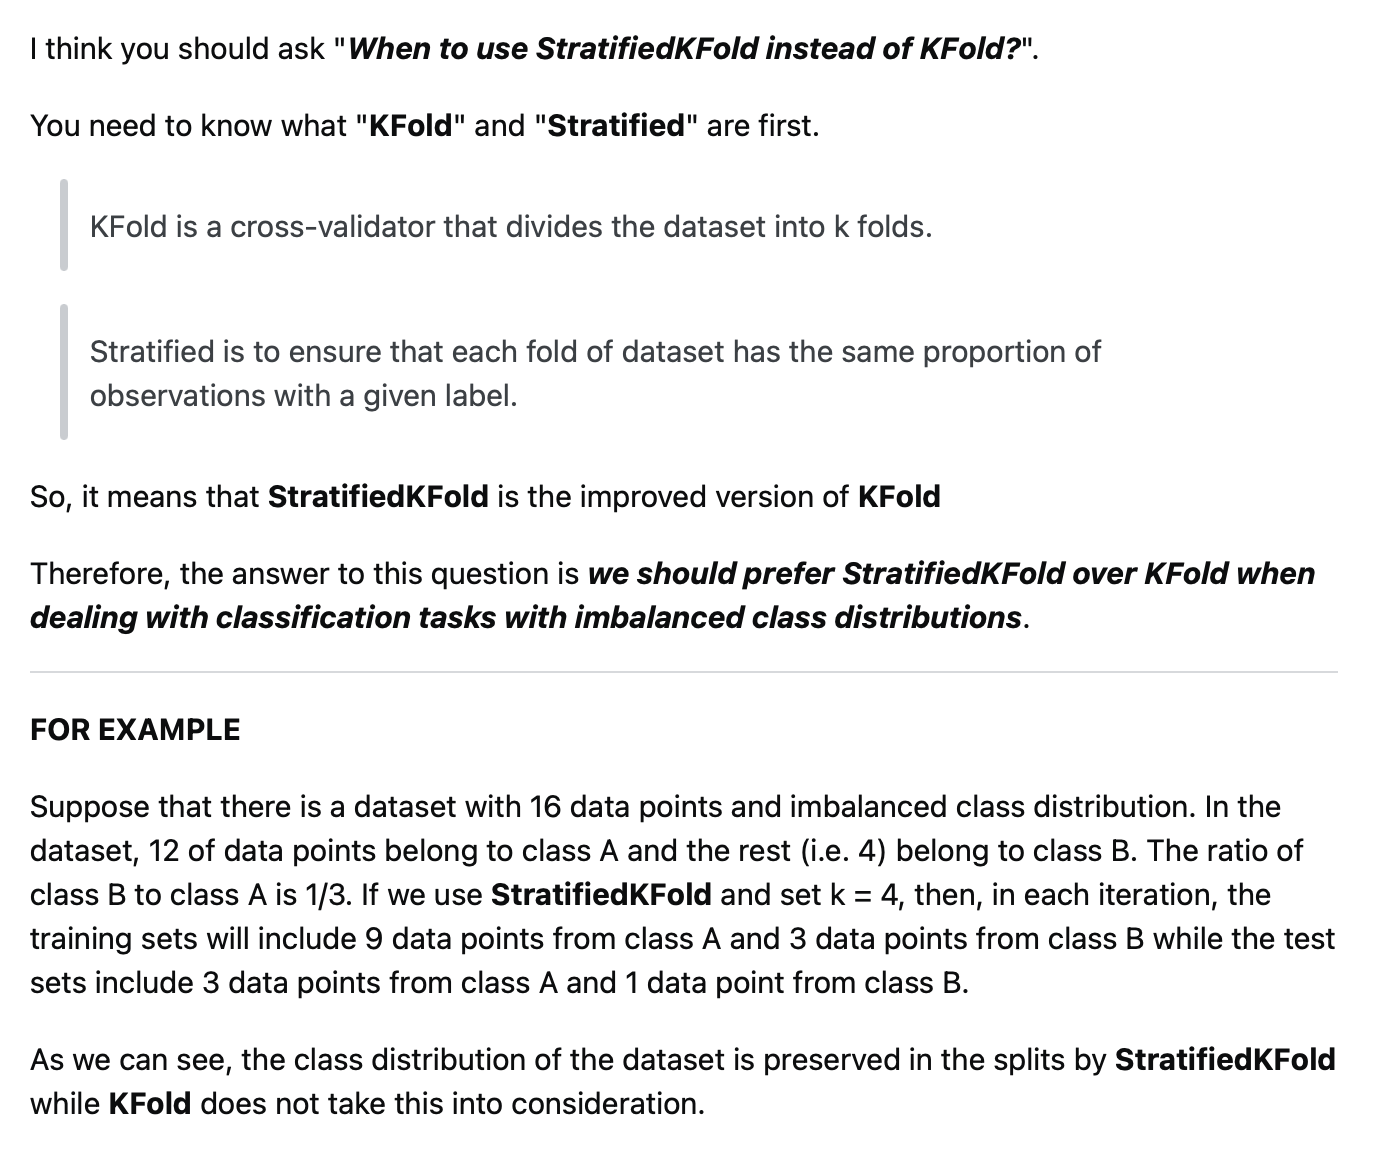 \
**Lec:** "KFold randomly splits data, hence does NOT ensure data splits are the same (only StratifiedKFold may ensure that)" \
=> The answer for using K-fold instead of StratifiedKFold for our training


I think the categorical feature (`Type`) is not much that *imbalanced* - Q


*Write something? Q - idk*

In [30]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits = 5, shuffle = True, random_state = 25)

# Evaluate LinearRegression
model = LinearRegression()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 1))}\n')


# Evaluate DecisionTreeRegressor
model = DecisionTreeRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 1))}\n')


# Evaluate RandomForestRegressor
model = RandomForestRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 1))}\n')


# Evaluate ElasticNet model
model = ElasticNet()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 1))}\n')


# Evaluate GradientBoostingRegressor
model = GradientBoostingRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 1))}\n')


# Evaluate Lasso model
model = Lasso(alpha = .1)
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 1))}\n')

LinearRegression rmse: [2.7 2.6 2.6 2.4 2.4]
Avg. rmse: 2.54

DecisionTreeRegressor rmse: [3.6 3.6 3.6 3.4 3.6]
Avg. rmse: 3.56

RandomForestRegressor rmse: [2.8 2.7 2.7 2.6 2.5]
Avg. rmse: 2.66

ElasticNet rmse: [2.8 2.8 2.7 2.6 2.5]
Avg. rmse: 2.68

GradientBoostingRegressor rmse: [2.6 2.6 2.6 2.4 2.4]
Avg. rmse: 2.52

Lasso rmse: [2.7 2.7 2.6 2.4 2.4]
Avg. rmse: 2.56



## 5. Hyperparameter Fine-tuning <a id="hyperparameter"></a>
"Random search is generally more efficient when the hyperparameter space is large and the optimal hyperparameters are not highly correlated, whereas grid search is more efficient when the hyperparameters are highly correlated and have a strong interaction effect." Link: https://360digitmg.com/blog/comparison-gridsearchcv-and-randomsearchcv#:~:text=Random%20search%20is%20generally%20more,have%20a%20strong%20interaction%20effect.

Now we will try to make the model more accurate, reduce the rmse score by tuning the parameters 

### 5.1. Support function <a id="hyperparameter_1"></a>
Function to print the output for fine-tune.

In [31]:
def print_search_result(grid_search, model_name = ""): 
    print("\n====== Fine-tune " + model_name +" ======")
    print('Best hyperparameter combination: ',grid_search.best_params_)
    print('Best rmse: ', np.sqrt(-grid_search.best_score_))  
    #print('Best estimator: ', grid_search.best_estimator_) # NOTE: require refit=True in  SearchCV
    print('Performance of hyperparameter combinations:')
    cv_results = grid_search.cv_results_
    for (mean_score, params) in zip(cv_results["mean_test_score"], cv_results["params"]):
        print('rmse =', np.sqrt(-mean_score), params) 

### 5.2. Grid serach <a id="hyperparameter_2"></a>

In [32]:
method = 1 # Grid search
if method == 1:
    from sklearn.model_selection import GridSearchCV
    cv = KFold(n_splits=5,shuffle=True,random_state=37) # cv data generator
        
    run_new_search = 1      
    if run_new_search:        
        
        # 5.1.1 Fine-tune LinearRegression
        model = LinearRegression()
        model_name = model.__class__.__name__
        param_grid = [
            # try (2x2)x2 combinations of hyperparameters 
            {'fit_intercept' : [True, False], 'copy_X' : [True, False], 'positive' : [True]},
            {'fit_intercept' : [True, False], 'copy_X' : [True, False], 'positive' : [False]},
            ]
            # Train cross 5 folds, hence a total of (12+12)*5=120 rounds of training 
        grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='neg_mean_squared_error', return_train_score=True, 
        refit=True) # refit=True: after finding best hyperparam, it fit() the model with whole data (hope to get better result)
        grid_search.fit(train_set, train_set_labels)
        store_model('grid_serach', grid_search, model_name)
        print_search_result(grid_search, model_name)


====== Fine-tune LinearRegression ======
Best hyperparameter combination:  {'copy_X': True, 'fit_intercept': True, 'positive': False}
Best rmse:  2.532849744798523
Performance of hyperparameter combinations:
rmse = nan {'copy_X': True, 'fit_intercept': True, 'positive': True}
rmse = 2.549259886946767 {'copy_X': True, 'fit_intercept': False, 'positive': True}
rmse = nan {'copy_X': False, 'fit_intercept': True, 'positive': True}
rmse = 2.549259886946767 {'copy_X': False, 'fit_intercept': False, 'positive': True}
rmse = 2.532849744798523 {'copy_X': True, 'fit_intercept': True, 'positive': False}
rmse = 2.5330151349182803 {'copy_X': True, 'fit_intercept': False, 'positive': False}
rmse = 2.532849744798523 {'copy_X': False, 'fit_intercept': True, 'positive': False}
rmse = 2.5330151349182803 {'copy_X': False, 'fit_intercept': False, 'positive': False}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
2 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/L

### 5.3. Random search <a id="hyperparameter_3"></a>

## 6. Model Testing and Analysis <a id="test_anal"></a>

## 7. References <a id="ref"></a>

## 8. Contribution <a id="contribution"></a>
|Student ID|Student Name|Contribution Rate <br> (1-100%)|Responsible for <br> (Parts, Cells...)|Note|
|------|------|------|------|------|
|s3983370|Le Kim Quyen| | | |
|s4070286|Ton Dat Toan| | | |
|s3979100|Nguyen Hong Ha| | | |
|s4045607|Huynh Bao Khoa Dang| | | |
|s4103086|Nguyen Viet Ngan Anh| | | |